## Personal notebook for decision tree by Marjaana Koski

### For this notebook the cleaned_100k.csv was used. The same skeleton from the main notebook was copied to ensure the same pipeline for the results comparison.

**Workflow**
1. Importing needed libraries
2. Data reading and splitting (copied from main notebook)
3. Creating skeleton (copied from main notebook)
4. Running Decision Tree without SMOTE or scaling, but with PCA and weighing
5. Running Decision Tree with SMOTE, PCA, weighing and without scaling
6. ??
7. create graphviz?


### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeClassifier


### Reading sampled csv and splitting data 60/20/20

In [6]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [7]:
# ---- Agreed 10-feature list ------------------------------------------
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, params_grid, label, use_smote=True, use_pca=True, use_scaler=False):
    steps = [("scaler", StandardScaler() if use_scaler else "passthrough")]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=params_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

all_results = []

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


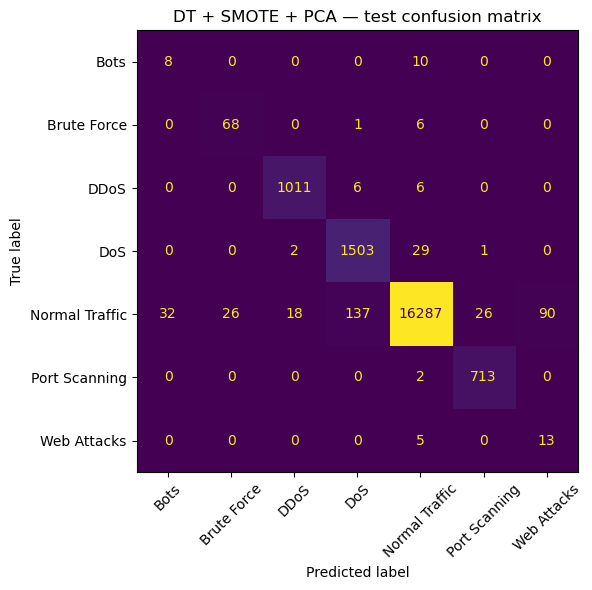


=== DT + SMOTE + PCA ===
Best params : {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 8}
Val  acc=0.9798  f1_macro=0.7557
Test acc=0.9801  f1_macro=0.7418
                precision    recall  f1-score   support

          Bots      0.200     0.444     0.276        18
   Brute Force      0.723     0.907     0.805        75
          DDoS      0.981     0.988     0.984      1023
           DoS      0.913     0.979     0.945      1535
Normal Traffic      0.996     0.980     0.988     16616
 Port Scanning      0.964     0.997     0.980       715
   Web Attacks      0.126     0.722     0.215        18

      accuracy                          0.980     20000
     macro avg      0.700     0.860     0.742     20000
  weighted avg      0.986     0.980     0.982     20000

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


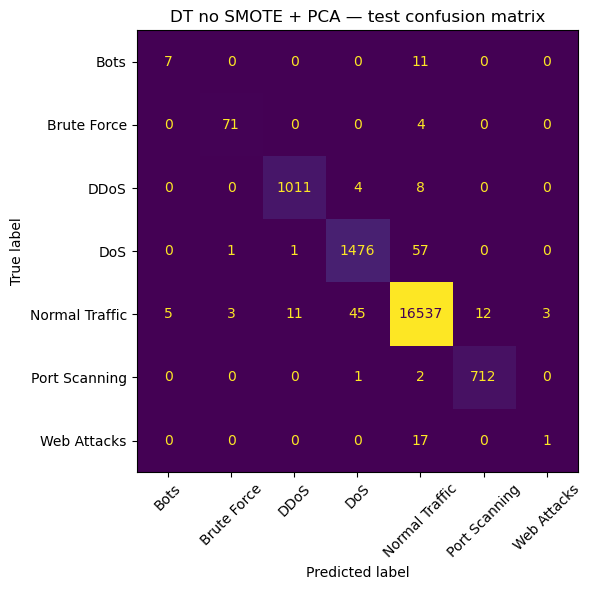


=== DT no SMOTE + PCA ===
Best params : {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 8}
Val  acc=0.9902  f1_macro=0.7763
Test acc=0.9908  f1_macro=0.7773
                precision    recall  f1-score   support

          Bots      0.583     0.389     0.467        18
   Brute Force      0.947     0.947     0.947        75
          DDoS      0.988     0.988     0.988      1023
           DoS      0.967     0.962     0.964      1535
Normal Traffic      0.994     0.995     0.995     16616
 Port Scanning      0.983     0.996     0.990       715
   Web Attacks      0.250     0.056     0.091        18

      accuracy                          0.991     20000
     macro avg      0.816     0.762     0.777     20000
  weighted avg      0.990     0.991     0.990     20000



In [8]:
dt_grid = {
    "pca__n_components":      [4, 6, 8],
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="DT + SMOTE + PCA", use_pca=True, use_smote=True)
)

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42), dt_grid,
                   label="DT no SMOTE + PCA", use_pca=True, use_smote=False)
)

In [10]:
for a in all_results:
    print(f"\n{a['label']}")
    print(f"  Best params : {a['best_params']}")
    print(f"  Val  f1_macro: {a['val_f1_macro']:.4f}")
    print(f"  Test f1_macro: {a['test_f1_macro']:.4f}")


DT + SMOTE + PCA
  Best params : {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'pca__n_components': 8}
  Val  f1_macro: 0.7557
  Test f1_macro: 0.7418

DT no SMOTE + PCA
  Best params : {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 8}
  Val  f1_macro: 0.7763
  Test f1_macro: 0.7773


### Running the model without SMOTE and scaling

### Creating confusion matrix without SMOTE and scaling

### Running the model with SMOTE, PCA, and weighing

In this part the model uses previously created method